In [3]:
import re
import ast
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from pathlib import Path
import seaborn as sns

sns.set_theme(style="whitegrid")

# ── Paths & data loading ──────────────────────────────────────────────────────
results_path   = Path("../../data/results/summary.xlsx")
abl_sub_path   = Path("../../data/results/ablation_study/gemini_flash_submitted.json")
add_steps_path = Path("../../data/results/ablation_study/ablation_1.json")

df_raw  = pd.read_excel(results_path, sheet_name="Raw summary")
df_acc  = pd.read_excel(results_path, sheet_name="Table 1 - accuracy")
df_clin = pd.read_excel(results_path, sheet_name="Table 2 - clinical info")
df_t4   = pd.read_excel(results_path, sheet_name="Table 4 - Non-submitted")
df_abl  = pd.read_excel(results_path, sheet_name="gemini_flash_ablation")
df_api  = pd.read_excel(results_path, sheet_name="gemini_api_test")

with abl_sub_path.open("r", encoding="utf-8") as f:
    df_abl_sub = pd.DataFrame(json.load(f))
with add_steps_path.open("r", encoding="utf-8") as f:
    steps_lookup = {
        e["id"]: int(e["metadata"]["max_steps"])
        for e in json.load(f)
        if "metadata" in e and "max_steps" in e.get("metadata", {})
    }
df_abl_sub["max_steps"] = df_abl_sub["task_id"].map(steps_lookup)

# ── Shared constants ──────────────────────────────────────────────────────────
TOTAL_FIELDS   = 36
POSITIVE_TYPES = {"1", "3a"}
N_BOOT         = 2000

LLM_ORDER   = ["gemini-3-pro-preview", "gemini-flash-latest", "claude-opus-4-5-20251101"]
LLM_DISPLAY = {
    "gemini-3-pro-preview":     "Gemini 3 Pro",
    "gemini-flash-latest":      "Gemini Flash",
    "claude-opus-4-5-20251101": "Claude Opus",
}
LLM_COLORS = {
    "gemini-3-pro-preview":     "#F28E2B",
    "gemini-flash-latest":      "#59A14F",
    "claude-opus-4-5-20251101": "#4E79A7",
}
OUTCOME_ORDER  = ["submitted", "technical error", "non-groundtruth issue", "correct withholding decision"]
OUTCOME_COLORS = {
    "submitted":                    "#59A14F",
    "technical error":              "#CCCF6D",
    "non-groundtruth issue":        "#F28E2B",
    "correct withholding decision": "#9C755F",
}

# ── Bootstrap helpers ─────────────────────────────────────────────────────────
def bootstrap_proportions(outcome_array, categories, n_boot, rng):
    """Vectorized bootstrap → {cat: (median, lo95, hi95)}."""
    n    = len(outcome_array)
    boot = outcome_array[rng.integers(0, n, size=(n_boot, n))]
    result = {}
    for cat in categories:
        props = (boot == cat).mean(axis=1)
        result[cat] = (np.median(props), *np.percentile(props, [2.5, 97.5]))
    return result

def bootstrap_kde_vectorized(vals, x_grid, n_boot, rng, chunk_size=40):
    """Vectorized bootstrap KDE with Scott's-rule bandwidth → (N_BOOT, G) density array."""
    n    = len(vals)
    h    = 1.06 * vals.std(ddof=1) * n ** (-0.2)
    boot = vals[rng.integers(0, n, size=(n_boot, n))]
    norm = 1.0 / (h * np.sqrt(2 * np.pi) * n)
    G, out = len(x_grid), np.empty((n_boot, len(x_grid)))
    for s in range(0, G, chunk_size):
        e = min(s + chunk_size, G)
        diff = x_grid[None, None, s:e] - boot[:, :, None]
        out[:, s:e] = norm * np.exp(-0.5 * (diff / h) ** 2).sum(axis=1)
    return out

# ── Combined task DataFrame ───────────────────────────────────────────────────
def _count_incorrect(raw):
    if pd.isna(raw):
        return 0
    try:
        return sum(1 for k in ast.literal_eval(str(raw)) if k != "icd_codes")
    except Exception:
        return 0

df_submitted = df_raw[(df_raw["completed"] == True) & (df_raw["submitted"] == True)][
    ["task_id", "cost", "llm", "sample_type", "completed", "incorrect_fields"]
].copy()
df_submitted["task_outcome"] = "submitted"

df_ns = df_t4[["task_id", "cost", "llm", "sample_type", "completed", "task_outcome"]].copy()
df_ns["task_outcome"] = df_ns["task_outcome"].replace(
    {"overrefusal error": "non-groundtruth issue", "error misattribution": "non-groundtruth issue"}
)

df_all = pd.concat([df_submitted, df_ns], ignore_index=True)
df_all["profile"]     = df_all["sample_type"].apply(lambda x: "Positive" if x in POSITIVE_TYPES else "Negative")
df_all["n_incorrect"] = df_all["incorrect_fields"].apply(_count_incorrect)
df_all["correct_pct"] = (TOTAL_FIELDS - df_all["n_incorrect"]) / TOTAL_FIELDS

df_abl_sub["n_incorrect"] = df_abl_sub["incorrect_fields"].apply(_count_incorrect)
df_abl_sub["correct_pct"] = (TOTAL_FIELDS - df_abl_sub["n_incorrect"]) / TOTAL_FIELDS

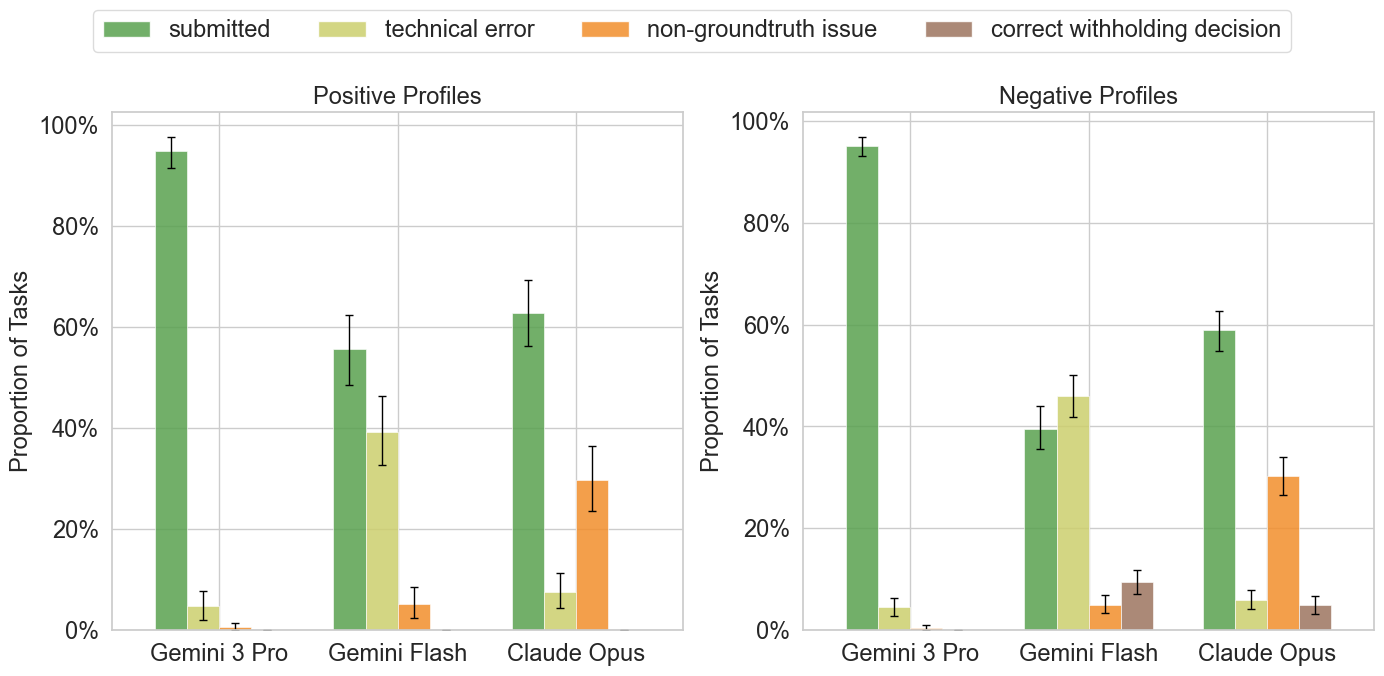

In [4]:
# Figure 2a. Task outcomes
rng = np.random.default_rng(42)

stats = {}
for llm in LLM_ORDER:
    for profile in ("Positive", "Negative"):
        grp  = df_all[(df_all["llm"] == llm) & (df_all["profile"] == profile)]
        vals = grp["task_outcome"].to_numpy(dtype=object)
        s    = bootstrap_proportions(vals, OUTCOME_ORDER, N_BOOT, rng)
        for outcome in OUTCOME_ORDER:
            stats[(llm, profile, outcome)] = s[outcome]

n_outcomes = len(OUTCOME_ORDER)
n_llms     = len(LLM_ORDER)
width      = 0.18
offsets    = (np.arange(n_outcomes) - (n_outcomes - 1) / 2) * width
x          = np.arange(n_llms)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)
fig.subplots_adjust(top=0.82, wspace=0.25)

legend_patches = {}
for ax, profile in zip(axes, ("Positive", "Negative")):
    for j, outcome in enumerate(OUTCOME_ORDER):
        color = OUTCOME_COLORS[outcome]
        meds  = [stats[(llm, profile, outcome)][0] for llm in LLM_ORDER]
        lo_e  = [stats[(llm, profile, outcome)][0] - stats[(llm, profile, outcome)][1] for llm in LLM_ORDER]
        hi_e  = [stats[(llm, profile, outcome)][2] - stats[(llm, profile, outcome)][0] for llm in LLM_ORDER]
        ax.bar(x + offsets[j], meds, width=width, color=color,
               alpha=0.85, edgecolor="white", linewidth=0.5)
        ax.errorbar(x + offsets[j], meds, yerr=[lo_e, hi_e],
                    fmt="none", color="black", capsize=3, linewidth=1.0, capthick=1.0)
        if outcome not in legend_patches:
            legend_patches[outcome] = mpatches.Patch(facecolor=color, alpha=0.85, label=outcome)

    ax.set_xticks(x)
    ax.set_xticklabels([LLM_DISPLAY[llm] for llm in LLM_ORDER], fontsize=17)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylabel("Proportion of Tasks", fontsize=17)
    ax.set_title(f"{profile} Profiles", fontsize=17)
    ax.set_xlim(-0.6, n_llms - 0.4)
    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=17)

handles = [legend_patches[o] for o in OUTCOME_ORDER]
fig.legend(handles, OUTCOME_ORDER,
           loc="upper center", ncol=n_outcomes,
           bbox_to_anchor=(0.5, 0.98), fontsize=17,
           frameon=True, edgecolor="lightgrey")
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

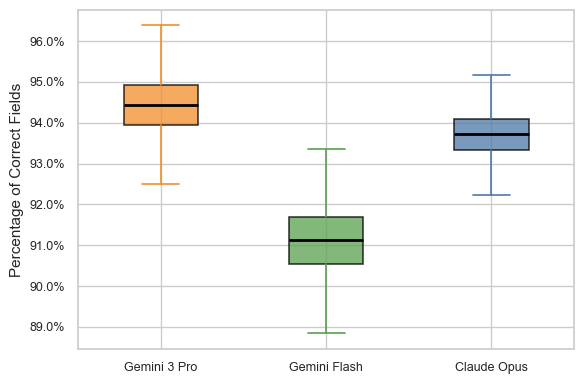

Bootstrapped mean accuracy (mean ± 95% CI):
  Gemini 3 Pro                    94.41%  [92.94%, 95.83%]
  Gemini Flash                    91.09%  [89.41%, 92.68%]
  Claude Opus                     93.70%  [92.52%, 94.70%]


In [5]:
# Figure 2b. Form-level accuracy
_sub_pos = df_all[(df_all["task_outcome"] == "submitted") & (df_all["profile"] == "Positive")]
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(6, 4))
boot_stats = {}
for i, llm in enumerate(LLM_ORDER, start=1):
    color = LLM_COLORS[llm]
    vals  = _sub_pos[_sub_pos["llm"] == llm]["correct_pct"].dropna().to_numpy(dtype=float)
    n     = len(vals)
    boot_means = vals[rng.integers(0, n, size=(N_BOOT, n))].mean(axis=1)
    boot_stats[llm] = {
        "mean": np.mean(boot_means),
        "lo95": np.percentile(boot_means, 2.5),
        "hi95": np.percentile(boot_means, 97.5),
    }
    ax.boxplot(boot_means, positions=[i], widths=0.45, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor=color, alpha=0.75, linewidth=1.2),
               medianprops=dict(color="black", linewidth=2.0),
               whiskerprops=dict(color=color, linewidth=1.2),
               capprops=dict(color=color, linewidth=1.2))

ax.set_xticks(range(1, len(LLM_ORDER) + 1))
ax.set_xticklabels([LLM_DISPLAY[llm] for llm in LLM_ORDER], fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Percentage of Correct Fields", fontsize=11)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

print("Bootstrapped mean accuracy (mean ± 95% CI):")
for llm in LLM_ORDER:
    s = boot_stats[llm]
    print(f"  {LLM_DISPLAY[llm]:30s}  {s['mean']:.2%}  [{s['lo95']:.2%}, {s['hi95']:.2%}]")

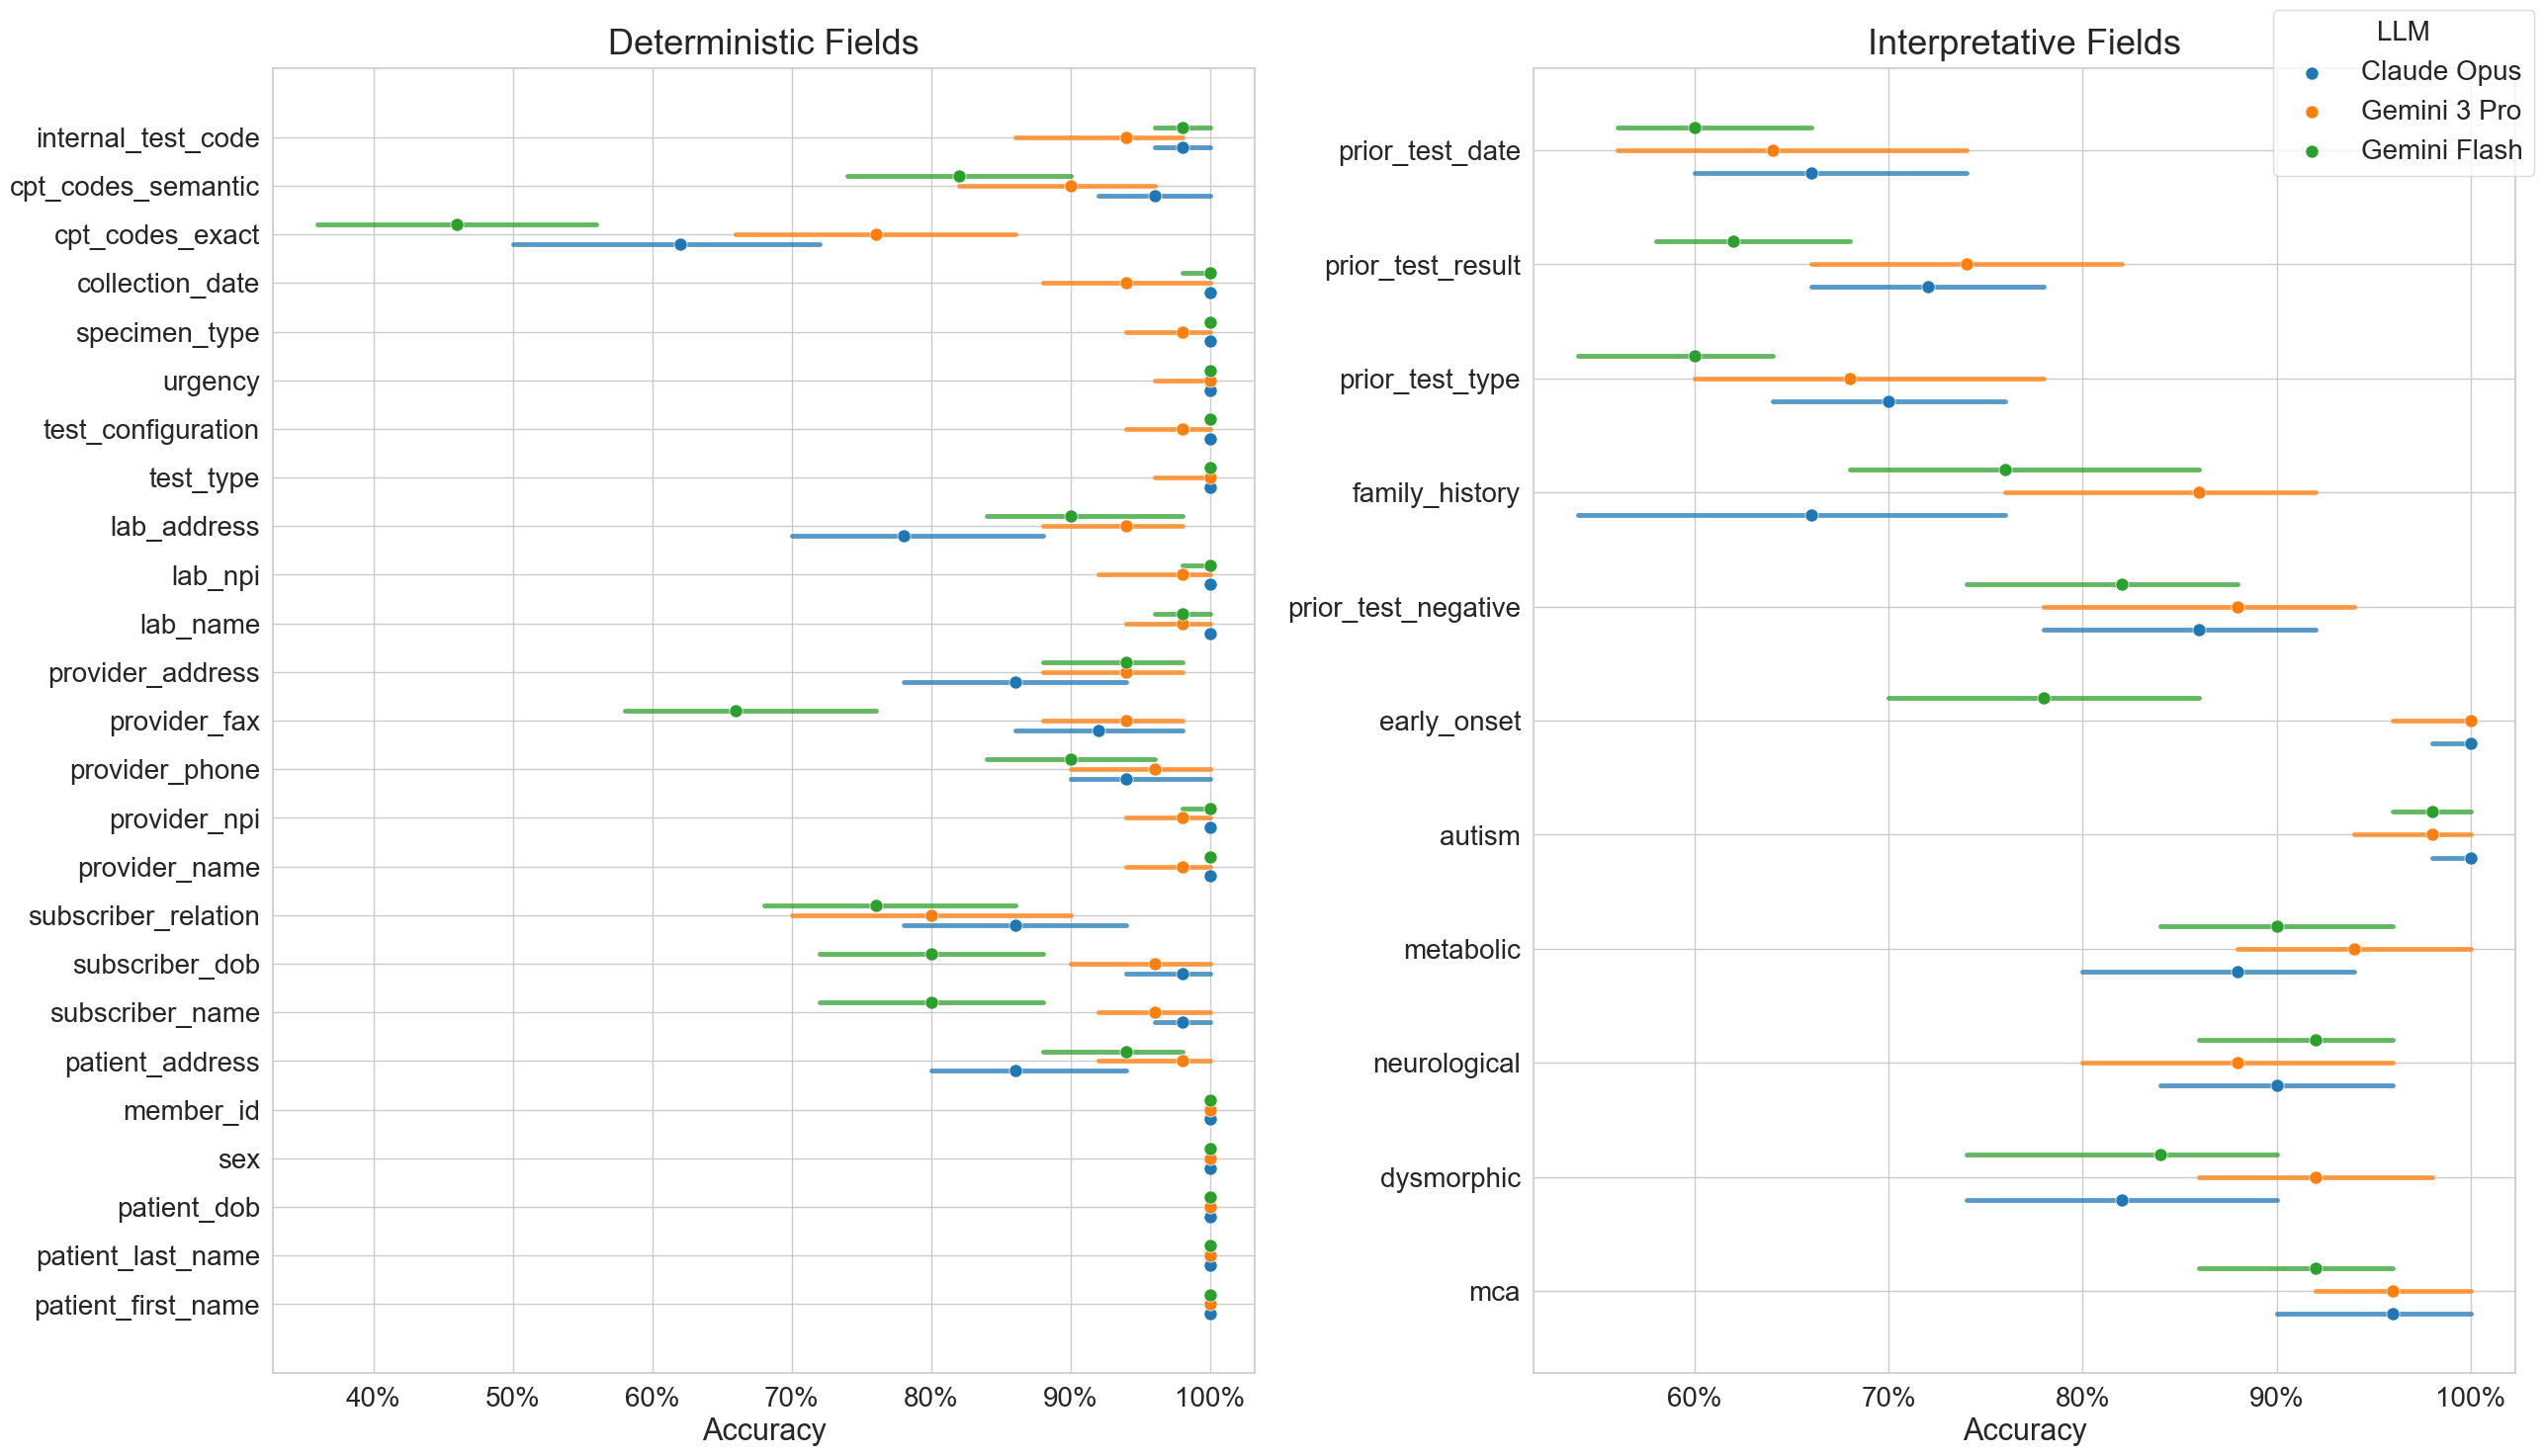

In [6]:
# Figure 2c. Accuracy by field
EXCLUDE_FIELDS_T1 = {"clinical_info", "cpt_codes"}
EXCLUDE_FIELDS_T2 = {"clinical_info", "icd_codes"}

llm_slugs = [re.sub(r"_bootstrap_median$", "", c)
             for c in df_acc.columns if c.endswith("_bootstrap_median")]

field_col = "field_type"
_acc  = df_acc[~df_acc[field_col].isin(EXCLUDE_FIELDS_T1)].reset_index(drop=True)
_clin = df_clin[~df_clin[field_col].isin(EXCLUDE_FIELDS_T2)].reset_index(drop=True)
fields_t1 = _acc[field_col].tolist()
fields_t2 = _clin[field_col].tolist()

tab10     = plt.get_cmap("tab10")
color_map = {slug: tab10(i % 10) for i, slug in enumerate(llm_slugs)}
n         = len(llm_slugs)
offsets   = (np.arange(n) - (n - 1) / 2) * 0.2
n_rows    = max(len(fields_t1), len(fields_t2))

rc = {
    "font.size": 22, "axes.titlesize": 26, "axes.labelsize": 22,
    "xtick.labelsize": 20, "ytick.labelsize": 20,
    "legend.fontsize": 20, "legend.title_fontsize": 20,
}
with plt.rc_context(rc):
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(26, max(6, n_rows * 0.6)))
    fig.subplots_adjust(wspace=0.35)
    legend_handles = {}

    for ax, title, fields, df in [
        (ax_left,  "Deterministic Fields",   fields_t1, _acc),
        (ax_right, "Interpretative Fields",  fields_t2, _clin),
    ]:
        y_pos = np.arange(len(fields))
        for i, slug in enumerate(llm_slugs):
            med   = pd.to_numeric(df[f"{slug}_bootstrap_median"], errors="coerce").to_numpy(dtype=float)
            lo    = pd.to_numeric(df[f"{slug}_ci_lower"],         errors="coerce").to_numpy(dtype=float)
            up    = pd.to_numeric(df[f"{slug}_ci_upper"],         errors="coerce").to_numpy(dtype=float)
            y     = y_pos + offsets[i]
            color = color_map[slug]
            label = LLM_DISPLAY.get(slug, slug)

            valid_ci = np.isfinite(lo) & np.isfinite(up)
            for yi, l, u in zip(y[valid_ci], lo[valid_ci], up[valid_ci]):
                ax.plot([l, u], [yi, yi], color=color, linewidth=3.5, alpha=0.75, solid_capstyle="round")

            valid_pts = np.isfinite(med)
            sc = ax.scatter(med[valid_pts], y[valid_pts], color=color, zorder=3, s=90,
                            edgecolors="white", linewidths=0.5)
            if label not in legend_handles:
                legend_handles[label] = sc

        ax.set_yticks(y_pos)
        ax.set_yticklabels(fields)
        ax.set_xlabel("Accuracy")
        ax.set_title(title, pad=10)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

    fig.legend(legend_handles.values(), legend_handles.keys(),
               title="LLM", loc="upper right", bbox_to_anchor=(1.0, 1.0),
               frameon=True, edgecolor="lightgrey")
    plt.tight_layout()
    plt.show()

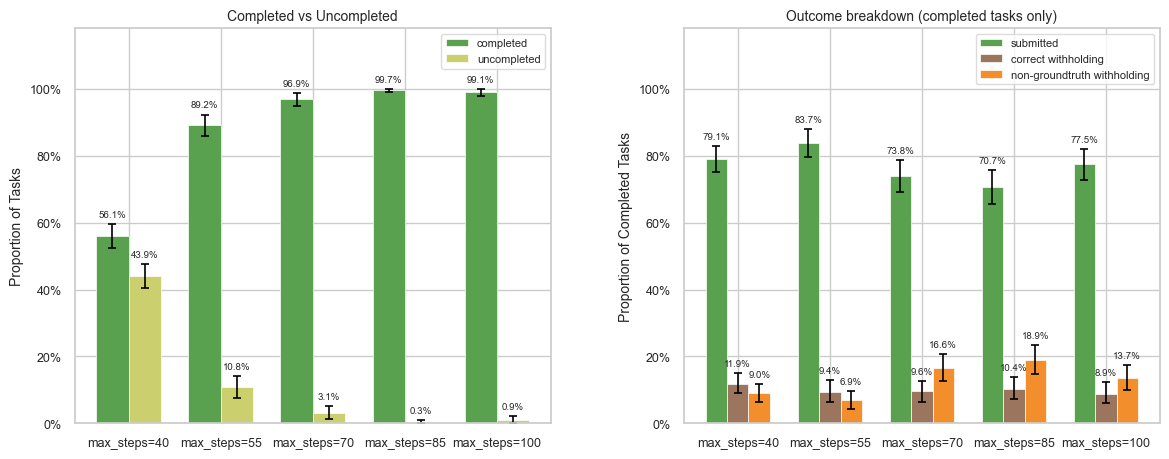

In [7]:
# Figure 3a. Gemini Flash ablation study — completed vs uncompleted by max_steps
gfl    = df_raw[df_raw["llm"] == "gemini-flash-latest"][["task_id", "completed", "submitted"]].copy()
gfl_t4 = df_t4[df_t4["llm"] == "gemini-flash-latest"][["task_id", "task_outcome"]]
gfl    = gfl.merge(gfl_t4, on="task_id", how="left")

outcome_40 = np.where(
    ~gfl["completed"], "uncompleted",
    np.where(gfl["submitted"], "submitted",
    np.where(gfl["task_outcome"] == "correct withholding decision",
             "correct withholding", "non-groundtruth withholding"))
)
df_40 = pd.DataFrame({"max_steps": 40, "outcome": outcome_40})

_abl = df_abl.dropna(subset=["max_steps"]).copy()
_abl["max_steps"] = _abl["max_steps"].astype(int)
outcome_abl = np.where(
    _abl["completed"] == 0, "uncompleted",
    np.where(_abl["submitted"],           "submitted",
    np.where(_abl["correct_withholding"], "correct withholding",
                                          "non-groundtruth withholding"))
)

df_abl_all         = pd.concat([df_40, pd.DataFrame({"max_steps": _abl["max_steps"].values, "outcome": outcome_abl})], ignore_index=True)
step_groups_sorted = sorted(df_abl_all["max_steps"].unique())
rng                = np.random.default_rng(42)

panel1_cats   = ["completed", "uncompleted"]
panel2_cats   = ["submitted", "correct withholding", "non-groundtruth withholding"]
panel1_colors = {"completed": "#59A14F", "uncompleted": "#CCCF6D"}
panel2_colors = {"submitted": "#59A14F", "correct withholding": "#9C755F", "non-groundtruth withholding": "#F28E2B"}

boot_p1, boot_p2 = {}, {}
for ms in step_groups_sorted:
    vals_all = df_abl_all[df_abl_all["max_steps"] == ms]["outcome"].to_numpy(dtype=object)
    boot_p1[ms] = bootstrap_proportions(
        np.where(vals_all == "uncompleted", "uncompleted", "completed"),
        panel1_cats, N_BOOT, rng
    )
    boot_p2[ms] = bootstrap_proportions(
        vals_all[vals_all != "uncompleted"], panel2_cats, N_BOOT, rng
    )

def plot_panel(ax, categories, colors, boot_data, step_groups, title):
    n_cats  = len(categories)
    width   = 0.7 / n_cats
    offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * width
    x       = np.arange(len(step_groups))
    for j, cat in enumerate(categories):
        meds = [boot_data[ms][cat][0] for ms in step_groups]
        lo_e = [boot_data[ms][cat][0] - boot_data[ms][cat][1] for ms in step_groups]
        hi_e = [boot_data[ms][cat][2] - boot_data[ms][cat][0] for ms in step_groups]
        bars = ax.bar(x + offsets[j], meds, width=width, color=colors[cat],
                      label=cat, edgecolor="white", linewidth=0.5)
        ax.errorbar(x + offsets[j], meds, yerr=[lo_e, hi_e],
                    fmt="none", color="black", capsize=3, linewidth=1.2, capthick=1.2)
        for bar, med, hi in zip(bars, meds, hi_e):
            ax.text(bar.get_x() + bar.get_width() / 2, med + hi + 0.015,
                    f"{med:.1%}", ha="center", va="bottom", fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"max_steps={ms}" for ms in step_groups], fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0, 1.18)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8, frameon=True, edgecolor="lightgrey")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.subplots_adjust(top=0.90, wspace=0.28)
plot_panel(ax1, panel1_cats, panel1_colors, boot_p1, step_groups_sorted, "Completed vs Uncompleted")
plot_panel(ax2, panel2_cats, panel2_colors, boot_p2, step_groups_sorted, "Outcome breakdown (completed tasks only)")
ax1.set_ylabel("Proportion of Tasks", fontsize=10)
ax2.set_ylabel("Proportion of Completed Tasks", fontsize=10)
plt.show()

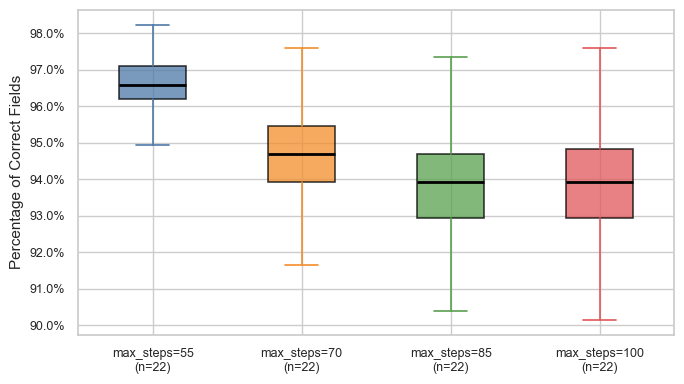

In [9]:
# Figure 3b. Ablation study — correct fields % by max_steps (bootstrapped boxplot)
_abl_pos = df_abl_sub[
    (df_abl_sub["submitted"] == True)
    & (df_abl_sub["sample_type"].isin(["1", "3a"]))
    & df_abl_sub["max_steps"].notna()
].copy()
_abl_pos["max_steps"] = _abl_pos["max_steps"].astype(int)

# Keep only patients present in all max_steps groups
all_steps    = set(_abl_pos["max_steps"].unique())
name_steps   = _abl_pos.groupby("patient_name")["max_steps"].apply(set)
names_in_all = name_steps[name_steps.apply(lambda s: s == all_steps)].index
_abl_pos     = _abl_pos[_abl_pos["patient_name"].isin(names_in_all)].copy()

step_order  = sorted(_abl_pos["max_steps"].unique())
step_colors = {55: "#4E79A7", 70: "#F28E2B", 85: "#59A14F", 100: "#E15759"}
rng         = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(7, 4))
for i, ms in enumerate(step_order, start=1):
    color      = step_colors.get(ms, "#888888")
    vals       = _abl_pos[_abl_pos["max_steps"] == ms]["correct_pct"].dropna().to_numpy(dtype=float)
    n          = len(vals)
    boot_means = vals[rng.integers(0, n, size=(N_BOOT, n))].mean(axis=1)
    ax.boxplot(boot_means, positions=[i], widths=0.45, patch_artist=True,
               showfliers=False,
               boxprops=dict(facecolor=color, alpha=0.75, linewidth=1.2),
               medianprops=dict(color="black", linewidth=2.0),
               whiskerprops=dict(color=color, linewidth=1.2),
               capprops=dict(color=color, linewidth=1.2))

labels = [f"max_steps={ms}\n(n={len(_abl_pos[_abl_pos['max_steps']==ms])})" for ms in step_order]
ax.set_xticks(range(1, len(step_order) + 1))
ax.set_xticklabels(labels, fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Percentage of Correct Fields", fontsize=11)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

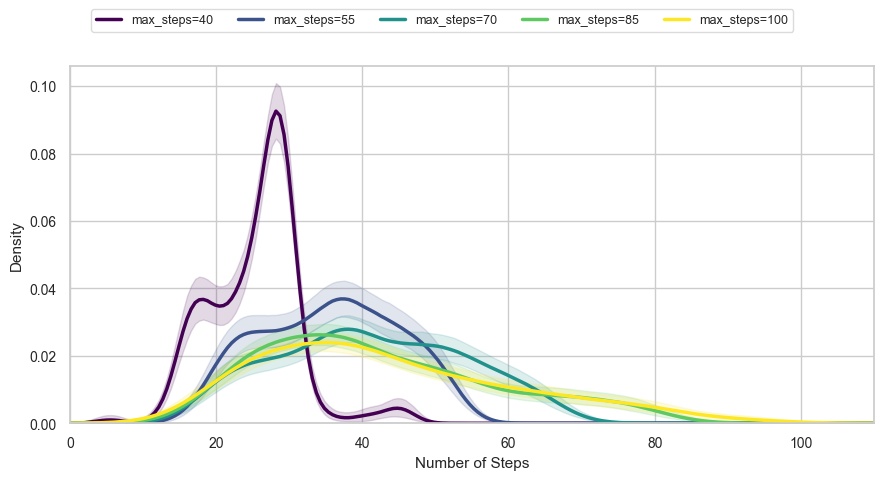

In [10]:
# Figure 3c. Step distribution
gfl_completed  = df_raw[(df_raw["llm"] == "gemini-flash-latest") & (df_raw["completed"] == True)]
steps_by_group = {40: gfl_completed["number_of_steps"].dropna().astype(float).values}

_abl = df_abl.dropna(subset=["max_steps"])
for ms in sorted(_abl["max_steps"].unique()):
    grp = _abl[(_abl["max_steps"] == ms) & (_abl["completed"] == 1)]
    steps_by_group[int(ms)] = grp["steps"].dropna().astype(float).values

step_groups_sorted = sorted(steps_by_group.keys())
cmap       = plt.get_cmap("viridis")
colors_kde = {ms: cmap(i / (len(step_groups_sorted) - 1)) for i, ms in enumerate(step_groups_sorted)}
rng        = np.random.default_rng(42)
x_grid     = np.linspace(0, 110, 200)

fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(top=0.88)
for ms in step_groups_sorted:
    boot_densities = bootstrap_kde_vectorized(steps_by_group[ms], x_grid, N_BOOT, rng)
    ax.plot(x_grid, np.median(boot_densities, axis=0),
            color=colors_kde[ms], linewidth=2.5, label=f"max_steps={ms}")
    ax.fill_between(x_grid,
                    np.percentile(boot_densities, 2.5,  axis=0),
                    np.percentile(boot_densities, 97.5, axis=0),
                    color=colors_kde[ms], alpha=0.15)

ax.set_xlabel("Number of Steps", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_ylim(bottom=0)
ax.set_xlim(0, x_grid[-1])
ax.tick_params(labelsize=10)
fig.legend(ax.lines, [l.get_label() for l in ax.lines],
           loc="upper center", ncol=len(step_groups_sorted),
           bbox_to_anchor=(0.5, 0.97), fontsize=9,
           frameon=True, edgecolor="lightgrey")
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

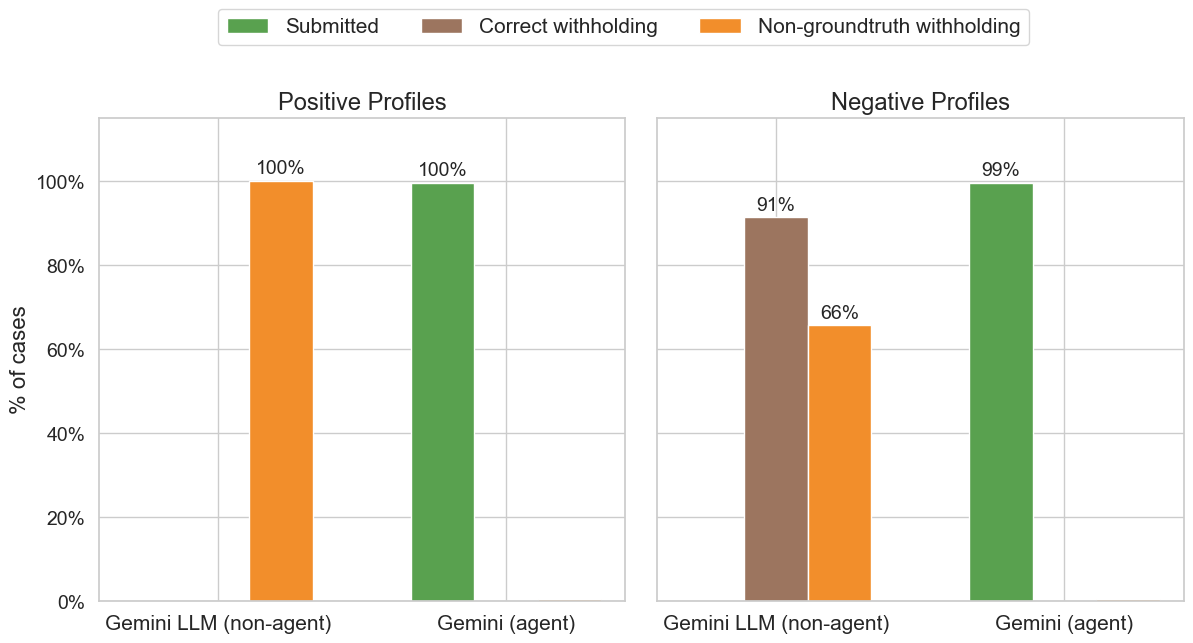

In [11]:
# Figure 4a. Agent VS chat function
pos_types = ["1", "3a"]
neg_types = ["2a", "2b", "2c", "3b"]

gemini_3_pro_raw = {
    "Technical error":          np.array([6, 2, 1, 6, 4, 11, 3]),
    "Submitted":                np.array([96, 104, 97, 99, 103, 94, 97]),
    "Non-groundtruth withhold": np.array([1, 0, 1, 0, 0, 1, 0]),
    "Correct withhold":         np.array([0, 0, 0, 0, 0, 0, 0]),
}
g3p_pos_idx = np.array([0, 4])
g3p_neg_idx = np.array([1, 2, 3, 5])

api_pos_df = df_api[df_api["sample_type"].isin(pos_types)]
api_neg_df = df_api[df_api["sample_type"].isin(neg_types)]

api_pos_pct = {
    "submit":                      api_pos_df["submit"].sum() / len(api_pos_df) * 100,
    "correct_withholding":         0.0,
    "non_groundtruth_withholding": api_pos_df["non_groundtruth_withholding"].sum() / len(api_pos_df) * 100,
}
api_neg_pct = {
    "submit":                      api_neg_df["submit"].sum() / len(api_neg_df) * 100,
    "correct_withholding":         api_neg_df["correct_withholding"].sum() / len(api_neg_df) * 100,
    "non_groundtruth_withholding": api_neg_df["non_groundtruth_withholding"].sum() / len(api_neg_df) * 100,
}

def _g3p_pct(indices, include_correct_w=True):
    sub   = int(gemini_3_pro_raw["Submitted"][indices].sum())
    cw    = int(gemini_3_pro_raw["Correct withhold"][indices].sum()) if include_correct_w else 0
    ngt   = int(gemini_3_pro_raw["Non-groundtruth withhold"][indices].sum())
    total = sub + cw + ngt
    if total == 0:
        return {"submit": 0.0, "correct_withholding": 0.0, "non_groundtruth_withholding": 0.0}
    return {"submit": sub/total*100, "correct_withholding": cw/total*100, "non_groundtruth_withholding": ngt/total*100}

g3p_pos_pct = _g3p_pct(g3p_pos_idx, include_correct_w=False)
g3p_neg_pct = _g3p_pct(g3p_neg_idx, include_correct_w=True)

cat_keys    = ["submit", "correct_withholding", "non_groundtruth_withholding"]
cat_labels  = ["Submitted", "Correct withholding", "Non-groundtruth withholding"]
cat_colors  = ["#59A14F", "#9C755F", "#F28E2B"]
model_labels = ["Gemini LLM (non-agent)", "Gemini (agent)"]
panels = [
    ("Positive Profiles", [api_pos_pct, g3p_pos_pct]),
    ("Negative Profiles", [api_neg_pct, g3p_neg_pct]),
]

x       = np.arange(len(model_labels))
n_cats  = len(cat_keys)
width   = 0.22
offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * width

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
fig.subplots_adjust(top=0.80, wspace=0.06)

legend_handles = []
for ax, (title, pcts) in zip(axes, panels):
    for j, (key, label, color) in enumerate(zip(cat_keys, cat_labels, cat_colors)):
        vals = [p[key] for p in pcts]
        bars = ax.bar(x + offsets[j], vals, width=width, color=color, label=label)
        if ax is axes[0]:
            legend_handles.append(bars)
        for bar, val in zip(bars, vals):
            if val > 1:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                        f"{val:.0f}%", ha="center", va="bottom", fontsize=14)
    ax.set_title(title, fontsize=17)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylim(0, 115)

axes[0].set_ylabel("% of cases", fontsize=16)
fig.legend(legend_handles, cat_labels, loc="upper center", ncol=3,
           bbox_to_anchor=(0.5, 0.97), fontsize=15)
plt.show()

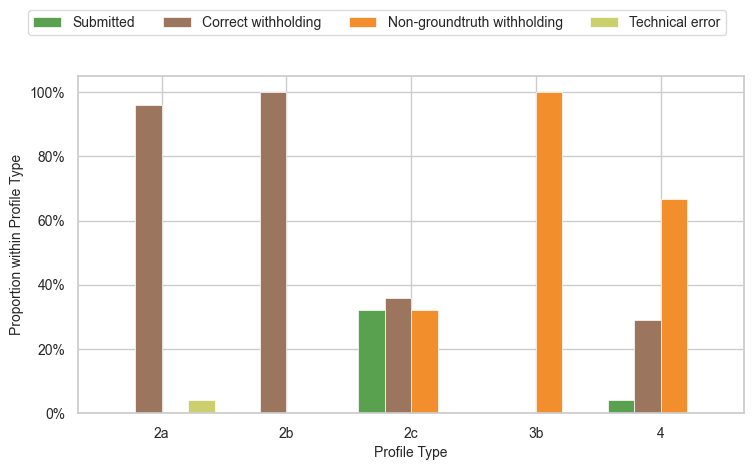

In [ ]:
# Figure 4b. Prompt specificity
sample_types = ["2a", "2b", "2c", "3b", "4"]
counts = {
    "submitted": np.array([0, 0, 8, 0, 1]),
    "correct_withholding": np.array([24, 25, 9, 0, 7]),
    "non_groundtruth_withholding": np.array([0, 0, 8, 25, 16]),
    "technical_errors": np.array([1, 0, 0, 0, 0])
}

cat_order  = ["submitted", "correct_withholding", "non_groundtruth_withholding", "technical_errors"]
cat_labels = ["Submitted", "Correct withholding", "Non-groundtruth withholding", "Technical error"]
cat_colors = ["#59A14F", "#9C755F", "#F28E2B", "#CCCF6D"]

# Convert to proportions column-wise
totals = np.sum([counts[c] for c in cat_order], axis=0).astype(float)
props  = {c: counts[c] / np.where(totals == 0, 1, totals) for c in cat_order}

n_cats = len(cat_order)
width  = 0.85 / n_cats
offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * width
x = np.arange(len(sample_types))

fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(top=0.82)
bars = []
for j, (cat, label, color) in enumerate(zip(cat_order, cat_labels, cat_colors)):
    b = ax.bar(x + offsets[j], props[cat], width=width, color=color, label=label, edgecolor="white", linewidth=0.5)
    bars.append(b)

ax.set_xticks(x)
ax.set_xticklabels(sample_types, fontsize=10)
ax.set_xlabel("Profile Type", fontsize=10)
ax.set_ylabel("Proportion within Profile Type", fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.tick_params(axis="y", labelsize=10)
fig.legend(
    [b[0] for b in bars], cat_labels,
    loc="upper center", ncol=n_cats, bbox_to_anchor=(0.5, 0.98),
    fontsize=10, frameon=True, edgecolor="lightgrey"
)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()